In [23]:
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Activation,Dropout,BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
def find_Class(directory_path):
    if not os.path.exists(directory_path):
        raise ValueError(f"The directory '{directory_path}' does not exist.")
    if not os.path.isdir(directory_path):
        raise ValueError(f"The path '{directory_path}' is not a directory.")
    
    all_entries = os.listdir(directory_path)
    
    folders = [entry for entry in all_entries if os.path.isdir(os.path.join(directory_path, entry))]
    
    return folders


In [3]:
DIRECTORY= r'/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train'
CATAGORIES= []
try:
    folders = find_Class(DIRECTORY)
    print(f"Directories in '{DIRECTORY}':")
    for folder in folders:
        CATAGORIES.append(folder)
except ValueError as e:
    print(e)

CATAGORIES


Directories in '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train':


['7', '2', '5', '3', '1', '4', '6']

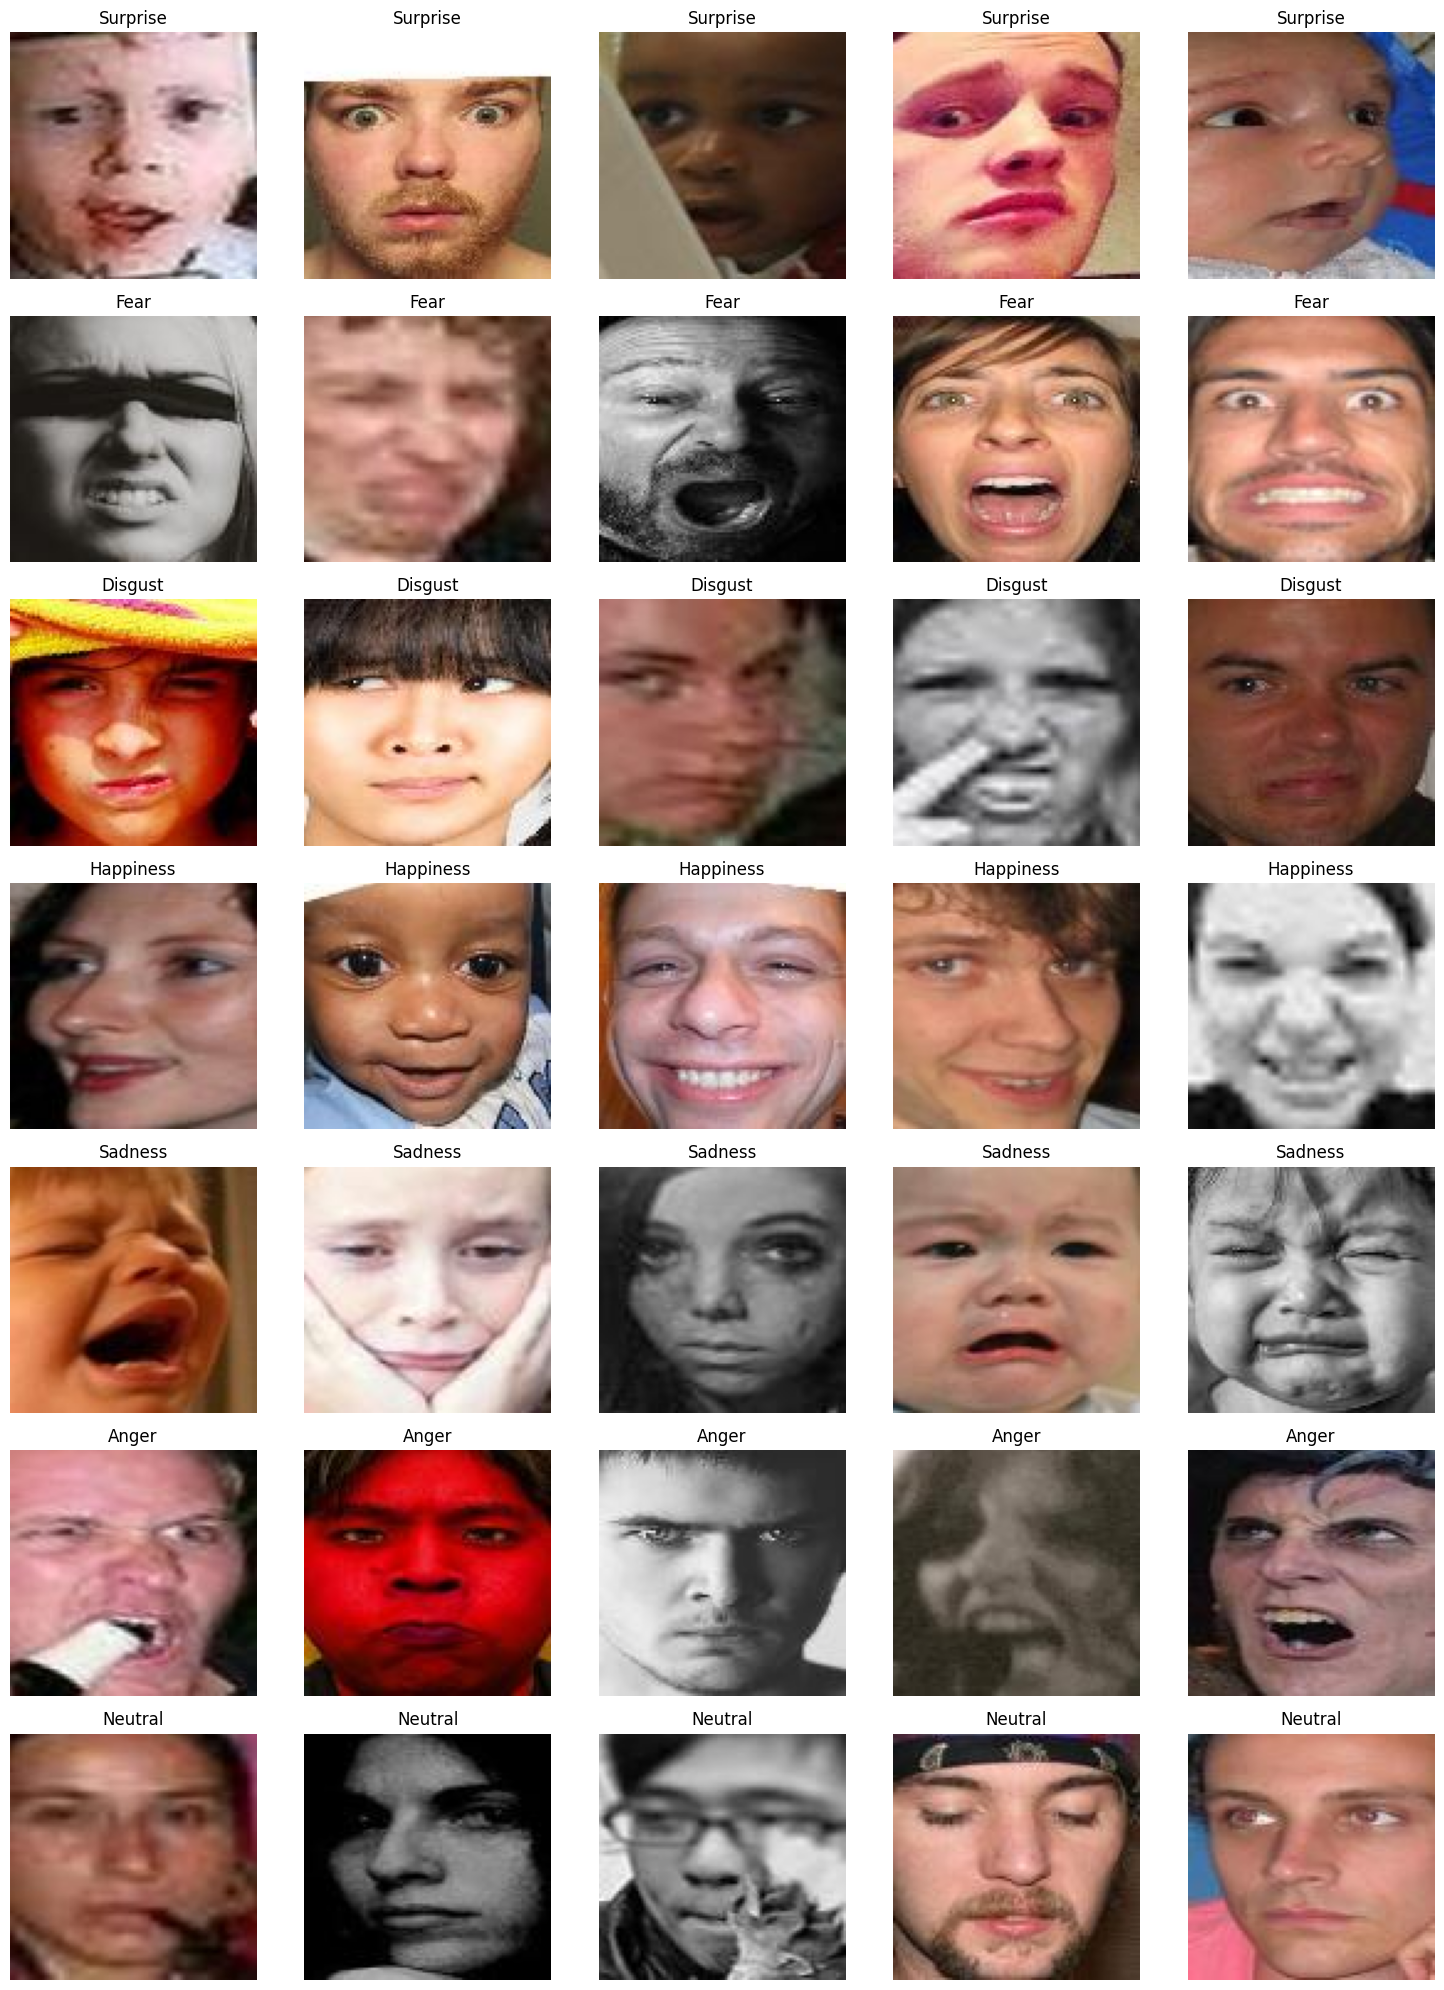

In [4]:
train_dir = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"

label_map = {
    '1': 'Surprise',
    '2': 'Fear',
    '3': 'Disgust',
    '4': 'Happiness',
    '5': 'Sadness',
    '6': 'Anger',
    '7': 'Neutral'
}

plt.figure(figsize=(15, 20))

i = 1
for label in sorted(os.listdir(train_dir)):
    class_dir = os.path.join(train_dir, label)
    images = os.listdir(class_dir)[:5]  # ambil 5 gambar

    for img_name in images:
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(7, 5, i)
        plt.imshow(img)
        plt.title(f"{label_map[label]}")
        plt.axis('off')
        i += 1

plt.tight_layout()
plt.show()

In [5]:
data=[]

for categories in CATAGORIES:
    folder=os.path.join(DIRECTORY,categories)
    label=CATAGORIES.index(categories)
    
    
    for img in os.listdir(folder):
        img=os.path.join(folder,img)
        img_arr=cv2.imread(img)
        if img_arr is not None:  # Check if the image is successfully loaded
            img_arr = cv2.resize(img_arr, (100, 100))
            data.append([img_arr, label])
        else:
            print(f"Failed to load image {img}")


In [6]:
len(data)

12271

In [7]:
DIRECTORY= r'/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test'
for categories in CATAGORIES:
    folder=os.path.join(DIRECTORY,categories)
    label=CATAGORIES.index(categories)
    
    
    for img in os.listdir(folder):
        img=os.path.join(folder,img)
        img_arr=cv2.imread(img)
        if img_arr is not None:
            img_arr = cv2.resize(img_arr, (100, 100))
            data.append([img_arr, label])
        else:
            print(f"Failed to load image {img}")

In [8]:
len(data)

15339

In [9]:
random.shuffle(data)

In [10]:
x=[]
y=[]


for features,label in data:
    x.append(features)
    y.append(label)

In [11]:
X= np.array(x)
Y=np.array(y)

In [12]:
X=X/255

In [13]:
X.shape

(15339, 100, 100, 3)

In [14]:
Y.shape

(15339,)

In [15]:
model=Sequential()
model.add( Conv2D(32,(3,3),input_shape=X.shape[1:],activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add( Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add( Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.5))


model.add(Flatten())
model.add(Dense(7,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774413722.217781    2993 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774413722.222875    2993 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        44,807 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,383 (396.03 KB)

 Trainable params: 101,255 (395.53 KB)

 Non-trainable params: 128 (512.00 B)

In [16]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
checkpoint=ModelCheckpoint(r'fer.keras',
                          monitor='val_accuracy',
                          mode='max',
                          save_best_only=True,
                          verbose=1)
earlystop=EarlyStopping(monitor='val_accuracy',
                        mode='max',
                       min_delta=0.001,
                       patience=10,
                       verbose=1,
                       restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

callbacks=[checkpoint,earlystop]


In [17]:
history = model.fit(X, Y, epochs=100, validation_split=0.25, callbacks=callbacks)

Epoch 1/100


I0000 00:00:1774413728.471982    3057 service.cc:152] XLA service 0x7be0c8025d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774413728.472019    3057 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774413728.472025    3057 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774413728.768988    3057 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/360 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1600 - loss: 3.2088

I0000 00:00:1774413733.001366    3057 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3280 - loss: 2.3658
Epoch 1: val_accuracy improved from -inf to 0.38670, saving model to fer.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.3281 - loss: 2.3650 - val_accuracy: 0.3867 - val_loss: 1.8455
Epoch 2/100
359/360 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4726 - loss: 1.6420
Epoch 2: val_accuracy improved from 0.38670 to 0.42503, saving model to fer.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4727 - loss: 1.6415 - val_accuracy: 0.4250 - val_loss: 1.5927
Epoch 3/100
356/360 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5444 - loss: 1.2918
Epoch 3: val_accuracy improved from 0.42503 to 0.54733, saving model to fer.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5445 - loss: 1.2915 - val_accuracy: 0.5473 - val_loss: 1.2524
Epoch 4/100
356/360 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5856 - loss: 1.1385
Epoch 4: val_accuracy improved from 0.54733 to 0.57523, saving

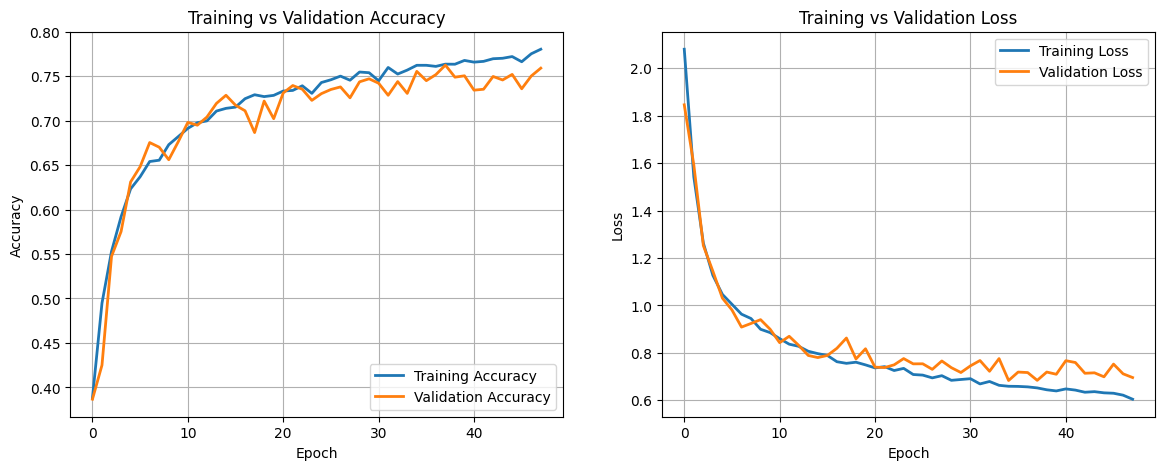

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

Melakukan prediksi...
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.71      0.86      0.78      3204
           1       0.94      0.55      0.69       355
           2       0.72      0.76      0.74      2460
           3       0.83      0.36      0.50       877
           4       0.88      0.81      0.85      1619
           5       0.91      0.92      0.92      5957
           6       0.83      0.71      0.77       867

    accuracy                           0.82     15339
   macro avg       0.83      0.71      0.75     15339
weighted avg       0.83      0.82      0.81     15339



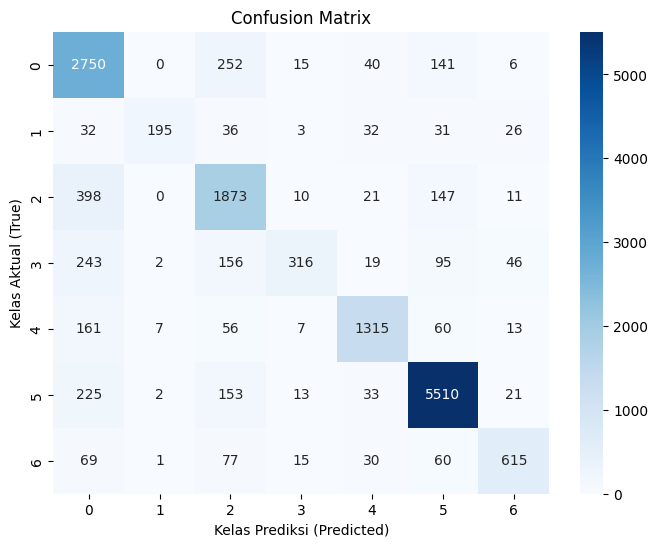

In [19]:
print("Melakukan prediksi...")
Y_pred_prob = model.predict(X)
Y_pred_classes = np.argmax(Y_pred_prob, axis=1)

if len(Y.shape) > 1 and Y.shape[1] > 1:
    Y_true_classes = np.argmax(Y, axis=1)
else:
    Y_true_classes = Y

print("\n--- Classification Report ---")
print(classification_report(Y_true_classes, Y_pred_classes))
cm = confusion_matrix(Y_true_classes, Y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Kelas Prediksi (Predicted)')
plt.ylabel('Kelas Aktual (True)')
plt.show()

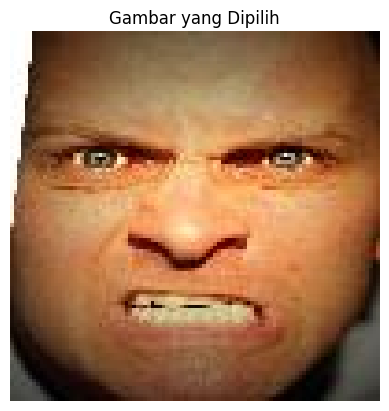

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

--- Hasil Prediksi ---
Gambar ini masuk ke Kelas Index: 6


In [52]:
image_path = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train/6/train_03630_aligned.jpg"
img = load_img(image_path, target_size=(100, 100))

plt.imshow(img)
plt.title("Gambar yang Dipilih")
plt.axis('off')
plt.show()

x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0

pred_prob = model.predict(x)
pred_class_index = np.argmax(pred_prob, axis=1)[0]

print("\n--- Hasil Prediksi ---")
print(f"Gambar ini masuk ke Kelas Index: {pred_class_index}")